# Modelo Naive Bayes para predecir `RainTomorrow`

Objetivo: construir un modelo supervisado de Naive Bayes para predecir si lloverá al día siguiente usando el dataset meteorológico de Australia.

La variable objetivo será `RainTomorrow`, donde `Yes` indica que sí lloverá al día siguiente y `No` indica que no lloverá.

## 1. Importación de librerías

Se importan las librerías necesarias para cargar datos, limpiar variables, construir el pipeline, entrenar el modelo y evaluar su rendimiento.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


## 2. Carga del dataset

El dataset se carga desde el repositorio indicado. También se deja la opción de leer un archivo local `weatherAUS.csv` si existe en la misma carpeta del notebook.

In [5]:
DATA_URL = "https://raw.githubusercontent.com/Darygarav/base-de-datos-australia/main/weatherAUS.csv"
LOCAL_DATASET = Path("weatherAUS.csv")
TARGET = "RainTomorrow"

def load_weather_data(url: str = DATA_URL) -> pd.DataFrame:
    if LOCAL_DATASET.exists():
        return pd.read_csv(LOCAL_DATASET)
    return pd.read_csv(url)

df = load_weather_data()

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
display(df.head())


Filas: 142,193
Columnas: 24


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


## 3. Revisión inicial de valores faltantes

Antes de entrenar el modelo se revisa el porcentaje de valores nulos. Esto permite decidir qué variables eliminar y cuáles imputar.

In [6]:
missing_df = pd.DataFrame({
    "Nulos": df.isna().sum(),
    "% faltante": (df.isna().sum() / len(df) * 100).round(2),
}).sort_values("% faltante", ascending=False)

display(missing_df[missing_df["Nulos"] > 0])


,Nulos,% faltante
Sunshine,67816,47.69
Evaporation,60843,42.79
Cloud3pm,57094,40.15
Cloud9am,53657,37.74
Pressure9am,14014,9.86
Pressure3pm,13981,9.83
WindDir9am,10013,7.04
WindGustDir,9330,6.56
WindGustSpeed,9270,6.52
WindDir3pm,3778,2.66


## 4. Limpieza de datos

Para este modelo se aplican las siguientes decisiones de limpieza:

- Se elimina `RISK_MM` porque representa fuga de información: contiene información directa sobre la lluvia del día siguiente.
- Se eliminan `Sunshine`, `Evaporation`, `Cloud3pm` y `Cloud9am` porque presentan un porcentaje alto de valores faltantes.
- Se transforma `Date` en `Year`, `Month` y `Day`, para conservar información temporal sin dejar la fecha como texto.
- Se convierte `RainTomorrow` a formato binario: `No = 0` y `Yes = 1`.
- No se eliminan filas con nulos en variables predictoras, porque esos valores serán tratados dentro del pipeline mediante imputación.

In [7]:
HIGH_MISSING_COLUMNS = ["Sunshine", "Evaporation", "Cloud3pm", "Cloud9am"]
LEAKAGE_COLUMNS = ["RISK_MM"]

def clean_weather_data(df: pd.DataFrame):
    data = df.copy()

    data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
    data["Year"] = data["Date"].dt.year
    data["Month"] = data["Date"].dt.month
    data["Day"] = data["Date"].dt.day
    data = data.drop(columns=["Date"])

    drop_columns = [col for col in HIGH_MISSING_COLUMNS + LEAKAGE_COLUMNS if col in data.columns]
    data = data.drop(columns=drop_columns)

    data = data[data[TARGET].notna()].copy()
    data[TARGET] = data[TARGET].map({"No": 0, "Yes": 1})
    data = data[data[TARGET].notna()].copy()
    data[TARGET] = data[TARGET].astype(int)

    X = data.drop(columns=[TARGET])
    y = data[TARGET]
    return X, y, data, drop_columns

X, y, clean_df, removed_columns = clean_weather_data(df)

print("Columnas eliminadas:", removed_columns)
print(f"Dataset limpio: {clean_df.shape[0]:,} filas y {clean_df.shape[1]} columnas")
print(f"Variables predictoras: {X.shape[1]}")
display(y.value_counts().rename(index={0: "No", 1: "Yes"}))
display(clean_df.head())


Columnas eliminadas: ['Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am', 'RISK_MM']
Dataset limpio: 142,193 filas y 21 columnas
Variables predictoras: 20


RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

,Location,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,...,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day
0,Albury,13.4,22.9,0.6,W,44.0,W,WNW,20.0,24.0,...,22.0,1007.7,1007.1,16.9,21.8,No,0,2008,12,1
1,Albury,7.4,25.1,0.0,WNW,44.0,NNW,WSW,4.0,22.0,...,25.0,1010.6,1007.8,17.2,24.3,No,0,2008,12,2
2,Albury,12.9,25.7,0.0,WSW,46.0,W,WSW,19.0,26.0,...,30.0,1007.6,1008.7,21.0,23.2,No,0,2008,12,3
3,Albury,9.2,28.0,0.0,NE,24.0,SE,E,11.0,9.0,...,16.0,1017.6,1012.8,18.1,26.5,No,0,2008,12,4
4,Albury,17.5,32.3,1.0,W,41.0,ENE,NW,7.0,20.0,...,33.0,1010.8,1006.0,17.8,29.7,No,0,2008,12,5


## 5. Justificación del preprocesamiento

Naive Bayes no puede trabajar directamente con valores nulos ni con variables categóricas en texto. Por eso se usa un pipeline de preprocesamiento:

- Variables numéricas: se imputan con la mediana, porque es robusta frente a valores atípicos.
- Variables categóricas: se imputan con la moda, porque reemplaza el valor faltante por una categoría real y frecuente.
- Variables categóricas: se codifican con One-Hot Encoding, porque variables como `Location`, `WindGustDir` o `RainToday` no tienen un orden natural.


In [8]:
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

print("Variables numéricas:", len(numeric_features))
print("Variables categóricas:", len(categorical_features))
print("Columnas numéricas:", numeric_features)
print("Columnas categóricas:", categorical_features)


Variables numéricas: 15
Variables categóricas: 5
Columnas numéricas: ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'Year', 'Month', 'Day']
Columnas categóricas: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']


## 6. División de datos

Se divide el dataset en entrenamiento y prueba. Se usa `stratify=y` para mantener la proporción original entre `No` y `Yes`, ya que la variable objetivo está desbalanceada.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")


X_train: (113754, 20)
X_test: (28439, 20)
y_train: (113754,)
y_test: (28439,)


## 7. Construcción y entrenamiento del modelo

Se construye un pipeline que primero aplica la limpieza necesaria y luego entrena el modelo `GaussianNB`.

`var_smoothing=1e-9` es el valor por defecto de `GaussianNB`. Este parámetro agrega una pequeña cantidad de estabilidad numérica al cálculo de varianzas, evitando problemas cuando una variable tiene varianza muy baja.

In [10]:
naive_bayes_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GaussianNB(var_smoothing=1e-9)),
])

naive_bayes_pipeline.fit(X_train, y_train)
y_pred = naive_bayes_pipeline.predict(X_test)

print("Modelo Naive Bayes entrenado correctamente.")


Modelo Naive Bayes entrenado correctamente.


## 8. Métricas del modelo

Como `RainTomorrow` está desbalanceada, no basta con mirar solo `Accuracy`. También se revisan `Precision_Yes`, `Recall_Yes` y `F1_Yes`, enfocadas en la clase `Yes`, que corresponde a los días en que sí lloverá.

In [11]:
metrics = {
    "Modelo": "Gaussian Naive Bayes",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision_Yes": precision_score(y_test, y_pred),
    "Recall_Yes": recall_score(y_test, y_pred),
    "F1_Yes": f1_score(y_test, y_pred),
}

metrics_df = pd.DataFrame([metrics])
display(metrics_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision_Yes": "{:.4f}",
    "Recall_Yes": "{:.4f}",
    "F1_Yes": "{:.4f}",
}));

print("Reporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))


,Modelo,Accuracy,Precision_Yes,Recall_Yes,F1_Yes
0,Gaussian Naive Bayes,0.6387,0.3492,0.7084,0.4678


Reporte de clasificación:
              precision    recall  f1-score   support

          No       0.88      0.62      0.73     22064
         Yes       0.35      0.71      0.47      6375

    accuracy                           0.64     28439
   macro avg       0.61      0.66      0.60     28439
weighted avg       0.76      0.64      0.67     28439



## 9. Matriz de confusión

La matriz de confusión permite observar cuántos casos fueron correctamente clasificados y cuántos errores cometió el modelo en cada clase.

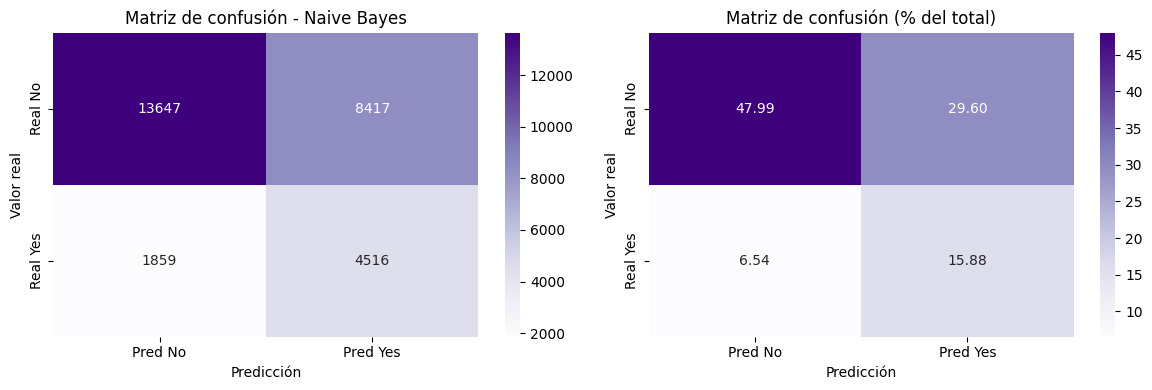

In [12]:
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm / cm.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    ax=axes[0],
    xticklabels=["Pred No", "Pred Yes"],
    yticklabels=["Real No", "Real Yes"],
)
axes[0].set_title("Matriz de confusión - Naive Bayes")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Valor real")

sns.heatmap(
    cm_pct,
    annot=True,
    fmt=".2f",
    cmap="Purples",
    ax=axes[1],
    xticklabels=["Pred No", "Pred Yes"],
    yticklabels=["Real No", "Real Yes"],
)
axes[1].set_title("Matriz de confusión (% del total)")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Valor real")

plt.tight_layout()
plt.show()


## 10. Interpretación automática de resultados

Esta celda genera una lectura breve del desempeño del modelo usando las métricas calculadas.

In [13]:
accuracy = metrics["Accuracy"]
precision_yes = metrics["Precision_Yes"]
recall_yes = metrics["Recall_Yes"]
f1_yes = metrics["F1_Yes"]

print(f"Accuracy general: {accuracy:.4f}")
print(f"Precisión para lluvia (Yes): {precision_yes:.4f}")
print(f"Recall para lluvia (Yes): {recall_yes:.4f}")
print(f"F1-score para lluvia (Yes): {f1_yes:.4f}")

if recall_yes > precision_yes:
    print("El modelo detecta una proporción relativamente alta de días lluviosos, pero puede generar falsos positivos.")
elif precision_yes > recall_yes:
    print("El modelo es más conservador al predecir lluvia: cuando predice Yes suele ser más preciso, pero puede dejar pasar días lluviosos.")
else:
    print("El modelo presenta un equilibrio similar entre precisión y recall para la clase Yes.")


Accuracy general: 0.6387
Precisión para lluvia (Yes): 0.3492
Recall para lluvia (Yes): 0.7084
F1-score para lluvia (Yes): 0.4678
El modelo detecta una proporción relativamente alta de días lluviosos, pero puede generar falsos positivos.


## Conclusión del modelo

En este notebook se construyó un modelo supervisado `GaussianNB` para predecir si lloverá al día siguiente mediante la variable objetivo `RainTomorrow`. Para ello se realizó una limpieza previa del dataset, eliminando columnas con alto porcentaje de valores faltantes y la variable `RISK_MM`, ya que representa fuga de información. También se transformó la fecha, se imputaron valores nulos y se codificaron las variables categóricas mediante One-Hot Encoding.

Naive Bayes es un modelo simple, rápido e interpretable. Su principal supuesto es que las variables predictoras son independientes entre sí dado el valor de la clase objetivo. En un problema meteorológico este supuesto no siempre se cumple completamente, ya que variables como temperatura, humedad y presión pueden estar relacionadas. Aun así, el modelo es útil como línea base para comparar contra modelos más complejos.

Para evaluar el desempeño se usaron métricas como `Accuracy`, `Precision_Yes`, `Recall_Yes`, `F1_Yes` y matriz de confusión. Debido al desbalance de `RainTomorrow`, es especialmente importante observar las métricas de la clase `Yes`, ya que esta clase representa los días en que efectivamente llueve y es menos frecuente en el dataset.

Como mejoras futuras se podrían probar ajuste de `var_smoothing`, validación cruzada, selección de variables, reducción de variables altamente correlacionadas, tratamiento del desbalance con técnicas como SMOTE o comparación con otros modelos supervisados como Decision Tree, Random Forest, Gradient Boosting o Regresión Logística.